In [13]:
import os
import pandas as pd

# Define the path to the downloads folder
downloads_path = '../../downloads'

# List of stock tickers
stock_list = [
    'AAPL', 'MSFT', 'GOOGL', 'NVDA', 'CRM', 'ORCL',
    'JNJ', 'PFE', 'MRK', 'ABT', 'BMY', 'TMO',
    'JPM', 'BAC', 'GS', 'MS', 'C', 'WFC',
    'AMZN', 'TSLA', 'NKE', 'HD', 'MCD', 'BKNG',
    'PG', 'KO', 'PEP', 'WMT', 'COST', 'KHC',
    'XOM', 'CVX', 'SLB', 'COP', 'PSX', 'MPC',
    'BA', 'HON', 'MMM', 'CAT', 'GE', 'DE',
    'VZ', 'T', 'CMCSA', 'TMUS', 'CHTR',
    'AMT', 'SPG', 'EQIX', 'O', 'CCI'
]

# Function to load data
def load_stock_data(ticker, directory):
    file_path = os.path.join(directory, f"{ticker}.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
        return df
    else:
        print(f"File for {ticker} not found.")
        return None

# Load all stock data into a dictionary of DataFrames
all_stock_data = {ticker: load_stock_data(ticker, downloads_path) for ticker in stock_list}

# Example: Display the first few rows of the AAPL DataFrame
aapl_data = all_stock_data['AAPL']
print(aapl_data.head())


                                Open       High        Low      Close  \
Date                                                                    
2014-06-25 00:00:00-04:00  19.948475  20.056830  19.824641  19.981646   
2014-06-26 00:00:00-04:00  19.983862  20.134233  19.857816  20.101063   
2014-06-27 00:00:00-04:00  20.083373  20.344311  20.072316  20.339890   
2014-06-30 00:00:00-04:00  20.366422  20.726871  20.364210  20.549963   
2014-07-01 00:00:00-04:00  20.680429  20.802054  20.594187  20.680429   

                              Volume  Dividends  Stock Splits  
Date                                                           
2014-06-25 00:00:00-04:00  147476000        0.0           0.0  
2014-06-26 00:00:00-04:00  130516000        0.0           0.0  
2014-06-27 00:00:00-04:00  256116000        0.0           0.0  
2014-06-30 00:00:00-04:00  197929200        0.0           0.0  
2014-07-01 00:00:00-04:00  152892000        0.0           0.0  


In [14]:
# Example: Print the Dividends and Stock Splits columns for AAPL
aapl_data = all_stock_data['AAPL']
print(aapl_data[['Dividends', 'Stock Splits']].head(10))

                           Dividends  Stock Splits
Date                                              
2014-06-25 00:00:00-04:00        0.0           0.0
2014-06-26 00:00:00-04:00        0.0           0.0
2014-06-27 00:00:00-04:00        0.0           0.0
2014-06-30 00:00:00-04:00        0.0           0.0
2014-07-01 00:00:00-04:00        0.0           0.0
2014-07-02 00:00:00-04:00        0.0           0.0
2014-07-03 00:00:00-04:00        0.0           0.0
2014-07-07 00:00:00-04:00        0.0           0.0
2014-07-08 00:00:00-04:00        0.0           0.0
2014-07-09 00:00:00-04:00        0.0           0.0


In [15]:
import ta

def preprocess_data(df):
    # Handle Missing Values
    df = df.dropna()

    # Feature Engineering: Adding moving averages
    df['20-Day MA'] = df['Close'].rolling(window=20).mean()
    df['50-Day MA'] = df['Close'].rolling(window=50).mean()
    df['200-Day MA'] = df['Close'].rolling(window=200).mean()

    # Feature Engineering: Adding moving averages for volume
    df['20-Day Volume MA'] = df['Volume'].rolling(window=20).mean()
    df['50-Day Volume MA'] = df['Volume'].rolling(window=50).mean()
    df['200-Day Volume MA'] = df['Volume'].rolling(window=200).mean()

    # Additional Technical Indicators
    df['EMA_20'] = ta.trend.ema_indicator(df['Close'], window=20)
    df['RSI'] = ta.momentum.rsi(df['Close'], window=14)
    df['MACD'] = ta.trend.macd_diff(df['Close'])
    df['Bollinger High'] = ta.volatility.bollinger_hband(df['Close'])
    df['Bollinger Low'] = ta.volatility.bollinger_lband(df['Close'])

    # Dropping rows with NaN values
    df = df.dropna()

    return df

# Apply preprocessing to all stock data
preprocessed_data = {ticker: preprocess_data(df) for ticker, df in all_stock_data.items()}

# Example: Display the first few rows of the preprocesses AAPL DataFrame
preprocessed_aapl_data = preprocessed_data['AAPL']
print(preprocessed_aapl_data.head())

                                Open       High        Low      Close  \
Date                                                                    
2015-04-10 00:00:00-04:00  28.222660  28.504999  28.068047  28.480350   
2015-04-13 00:00:00-04:00  28.764920  28.809739  28.370544  28.424322   
2015-04-14 00:00:00-04:00  28.457941  28.522923  28.213696  28.301086   
2015-04-15 00:00:00-04:00  28.325732  28.487067  28.236100  28.408640   
2015-04-16 00:00:00-04:00  28.296600  28.480345  28.258508  28.271952   

                              Volume  Dividends  Stock Splits  20-Day MA  \
Date                                                                       
2015-04-10 00:00:00-04:00  160752000        0.0           0.0  28.180195   
2015-04-13 00:00:00-04:00  145460400        0.0           0.0  28.216719   
2015-04-14 00:00:00-04:00  102098400        0.0           0.0  28.231844   
2015-04-15 00:00:00-04:00  115881600        0.0           0.0  28.228931   
2015-04-16 00:00:00-04:00  11347

In [17]:
# Verifying data types and summary stats
print(preprocessed_aapl_data.info())
print(preprocessed_aapl_data.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 2317 entries, 2015-04-10 00:00:00-04:00 to 2024-06-24 00:00:00-04:00
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Open               2317 non-null   float64
 1   High               2317 non-null   float64
 2   Low                2317 non-null   float64
 3   Close              2317 non-null   float64
 4   Volume             2317 non-null   int64  
 5   Dividends          2317 non-null   float64
 6   Stock Splits       2317 non-null   float64
 7   20-Day MA          2317 non-null   float64
 8   50-Day MA          2317 non-null   float64
 9   200-Day MA         2317 non-null   float64
 10  20-Day Volume MA   2317 non-null   float64
 11  50-Day Volume MA   2317 non-null   float64
 12  200-Day Volume MA  2317 non-null   float64
 13  EMA_20             2317 non-null   float64
 14  RSI                2317 non-null   float64
 15  MACD               2317 non-null

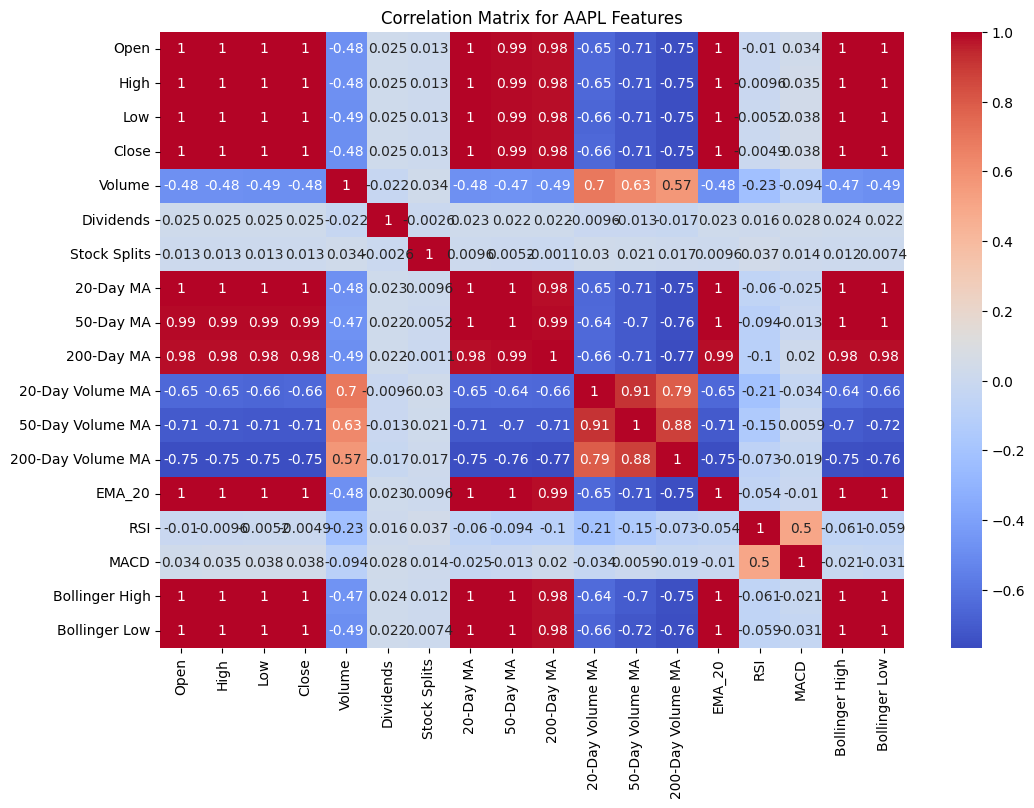

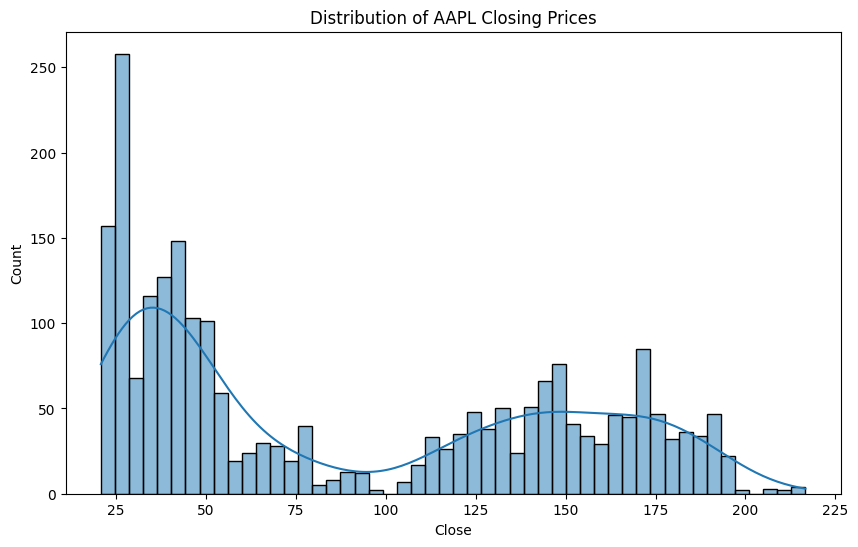

<Figure size 1400x700 with 0 Axes>

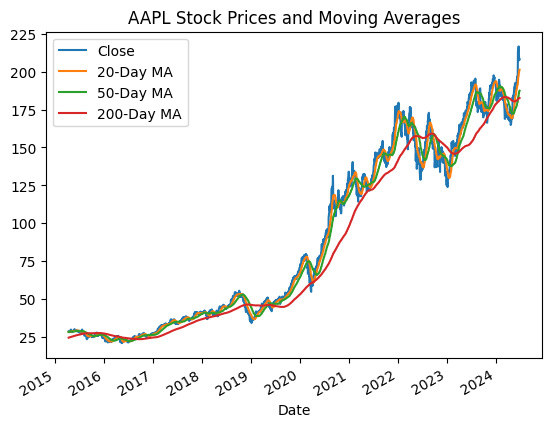

<Figure size 1400x700 with 0 Axes>

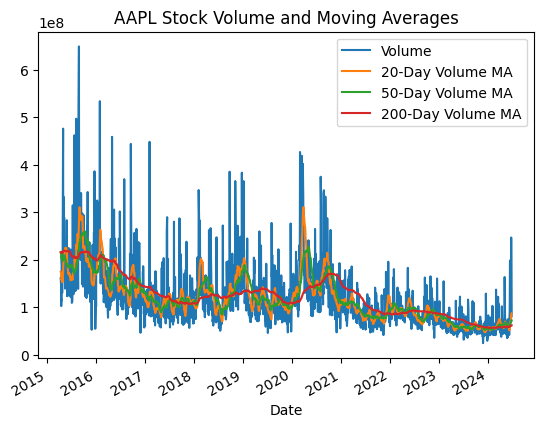

In [23]:
# Correlation Analysis
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the EDA visuals
def plot_eda(preprocessed_data, ticker):
    # Extract data for the given ticker
    df = preprocessed_data[ticker]

    # Correlation Matrix
    plt.figure(figsize=(12, 8))
    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
    plt.title(f'Correlation Matrix for {ticker} Features')
    plt.show()

    # Distribution Plot
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Close'], bins=50, kde=True)
    plt.title(f'Distribution of {ticker} Closing Prices')

    # Time Series Analysis
    plt.figure(figsize=(14, 7))
    df[['Close', '20-Day MA', '50-Day MA', '200-Day MA']].plot()
    plt.title(f'{ticker} Stock Prices and Moving Averages')
    plt.show()

    # Volume Analysis
    plt.figure(figsize=(14, 7))
    df[['Volume', '20-Day Volume MA', '50-Day Volume MA', '200-Day Volume MA']].plot()
    plt.title(f'{ticker} Stock Volume and Moving Averages')
    plt.show()

plot_eda(preprocessed_data, 'AAPL')